         loan_id         PD        LGD          EAD          EL
count  1000.0000  1000.0000  1000.0000    1000.0000   1000.0000
mean    499.5000     0.0205     0.4159  182579.9783   1568.7187
std     288.8194     0.0137     0.2052   97613.5989   1858.8423
min       0.0000     0.0004     0.0087   32596.8651      6.2496
25%     249.7500     0.0101     0.2558  114039.7448    441.4411
50%     499.5000     0.0175     0.4056  161336.0966    992.1772
75%     749.2500     0.0273     0.5671  227523.1317   1963.2130
max     999.0000     0.0848     0.9131  837519.3715  20155.8362
Portfolio total exposure : €182.6M
Mean loss rate           : 0.85%
99.9th percentile loss   : 7.72%
ρ=0.01 | mean=0.86% | 99.9p=2.09%
ρ=0.15 | mean=0.88% | 99.9p=7.08%
ρ=0.40 | mean=0.85% | 99.9p=17.14%
     name rating_target  notional_M  mean_loss  prob_any_loss  loss_99p
   Junior            BB      18.258     0.0854         0.9802    0.4449
Mezzanine           BBB      36.516     0.0000         0.0003    0.0000
   S

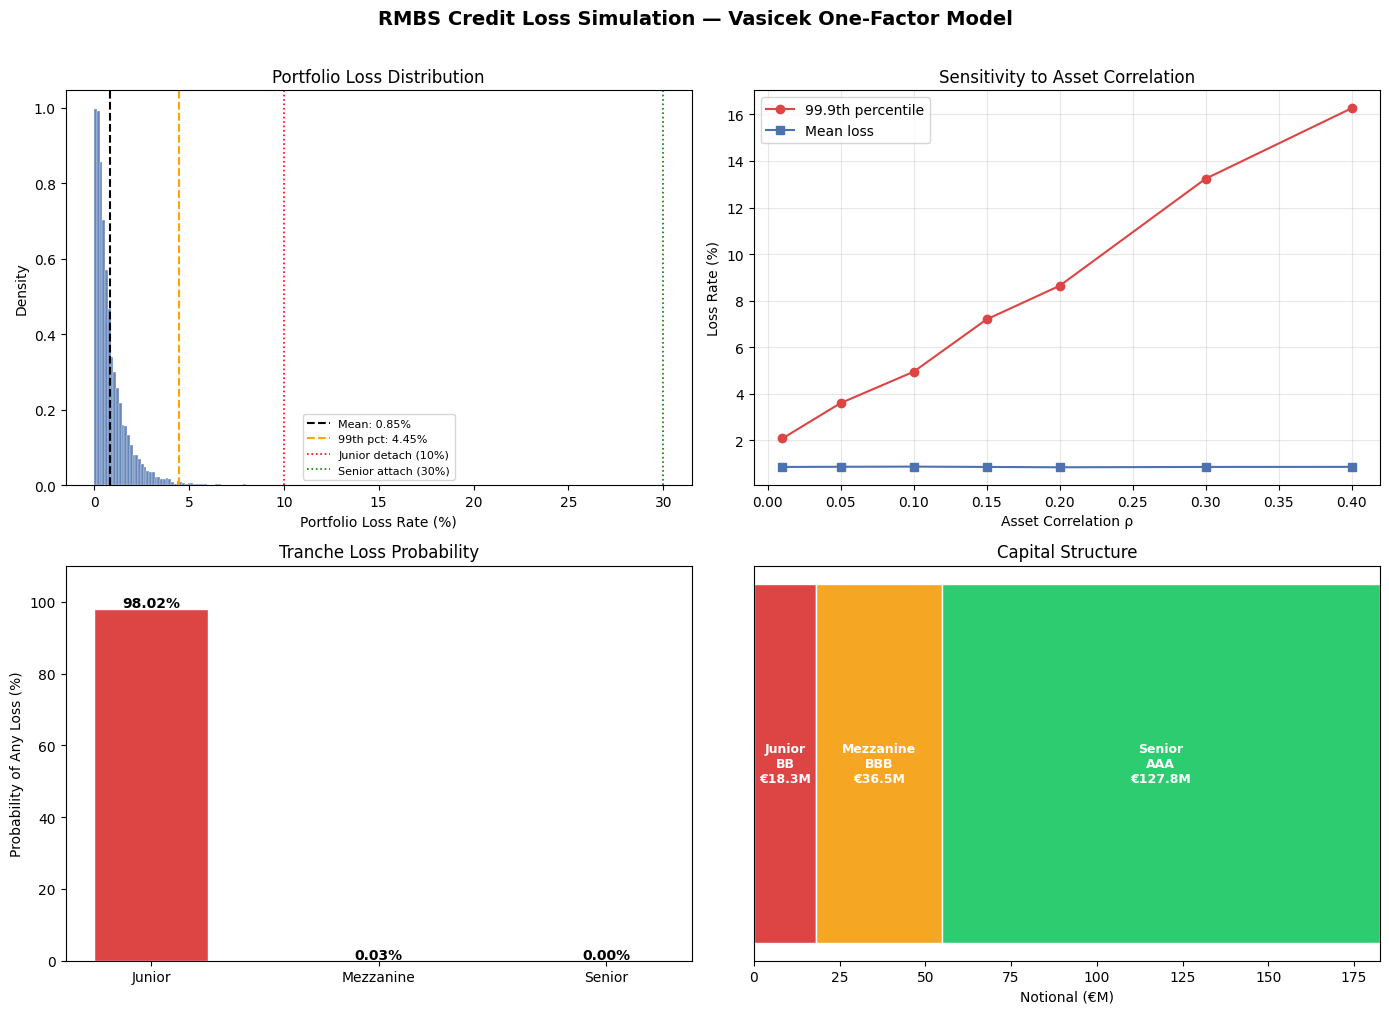

✓ Figure saved → rmbs_simulation.png


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

#1. PORTFOLIO GENERATION

def generate_portfolio(n_loans: int = 1000) -> pd.DataFrame:
    """
    Generate a synthetic RMBS loan portfolio.
    
    Each loan has:
      - PD  : annual probability of default (Beta distribution → always in [0,1])
      - LGD : loss given default (Beta distribution)
      - EAD : exposure at default in € (LogNormal → always positive)
    """
    pd_values  = np.random.beta(a=2, b=98, size=n_loans)   # mean ~2%
    lgd_values = np.random.beta(a=2, b=3,  size=n_loans)   # mean ~40%
    ead_values = np.random.lognormal(mean=12, sigma=0.5, size=n_loans)  # ~€160k

    return pd.DataFrame({
        "loan_id" : np.arange(n_loans),
        "PD"      : pd_values,
        "LGD"     : lgd_values,
        "EAD"     : ead_values,
        "EL"      : pd_values * lgd_values * ead_values,   # Expected Loss
    })

portfolio = generate_portfolio()
print(portfolio.describe().round(4))

from scipy.stats import norm

#2. MONTE CARLO SIMULATION

def simulate_losses(
    portfolio: pd.DataFrame,
    n_simulations: int = 10_000,
    rho: float = 0.15,          # asset correlation
) -> np.ndarray:
    """
    One-factor Vasicek model.
    
    For each simulation:
      1. Draw a systematic factor Z  (the 'economy')
      2. Draw idiosyncratic shocks ε per loan
      3. Compute asset value A = sqrt(ρ)·Z + sqrt(1-ρ)·ε
      4. Loan defaults if A < Φ⁻¹(PD)
      5. Loss = LGD × EAD  if default, else 0
    """
    PD  = portfolio["PD"].values   # shape (n_loans,)
    LGD = portfolio["LGD"].values
    EAD = portfolio["EAD"].values

    # Default thresholds : Φ⁻¹(PDᵢ)
    thresholds = norm.ppf(PD)                              # (n_loans,)

    # Systematic factor : one per simulation
    Z = np.random.normal(size=(n_simulations, 1))          # (n_sims, 1)

    # Idiosyncratic shocks : one per loan per simulation
    eps = np.random.normal(size=(n_simulations, len(PD)))  # (n_sims, n_loans)

    # Asset values
    A = np.sqrt(rho) * Z + np.sqrt(1 - rho) * eps         # (n_sims, n_loans)

    # Default indicator : 1 if default, 0 otherwise
    defaults = (A < thresholds).astype(float)              # (n_sims, n_loans)

    # Loss per simulation (€)
    loss_per_loan = defaults * LGD * EAD                   # (n_sims, n_loans)
    total_losses  = loss_per_loan.sum(axis=1)              # (n_sims,)

    return total_losses

losses = simulate_losses(portfolio)

#Quick stats
total_portfolio = portfolio["EAD"].sum()
loss_rate = losses / total_portfolio

print(f"Portfolio total exposure : €{total_portfolio/1e6:.1f}M")
print(f"Mean loss rate           : {loss_rate.mean()*100:.2f}%")
print(f"99.9th percentile loss   : {np.percentile(loss_rate, 99.9)*100:.2f}%")

for rho in [0.01, 0.15, 0.40]:
    l = simulate_losses(portfolio, rho=rho)
    r = l / portfolio["EAD"].sum()
    print(f"ρ={rho:.2f} | mean={r.mean()*100:.2f}% | 99.9p={np.percentile(r,99.9)*100:.2f}%")

#3. TRANCHE WATERFALL

def define_tranches(total_exposure: float) -> list[dict]:
    """
    Define the capital structure of the RMBS.
    attachment/detachment points are expressed as % of total portfolio.
    """
    return [
        {"name": "Junior",     "attach": 0.00, "detach": 0.10, "rating_target": "BB"},
        {"name": "Mezzanine",  "attach": 0.10, "detach": 0.30, "rating_target": "BBB"},
        {"name": "Senior",     "attach": 0.30, "detach": 1.00, "rating_target": "AAA"},
    ]

def apply_waterfall(
    losses: np.ndarray,
    total_exposure: float,
    tranches: list[dict],
) -> pd.DataFrame:
    """
    For each simulation, compute how much loss each tranche absorbs.
    
    Tranche loss = max(0, min(loss, detach) - attach)
    expressed as % of tranche notional.
    """
    loss_rate = losses / total_exposure   # (n_sims,) as fraction

    results = []
    for t in tranches:
        attach  = t["attach"]
        detach  = t["detach"]
        notional = (detach - attach) * total_exposure

        # Loss absorbed by this tranche (as fraction of portfolio)
        tranche_loss_rate = (
            np.clip(loss_rate, attach, detach) - attach
        ) / (detach - attach)                          # normalized to tranche size

        results.append({
            "name"          : t["name"],
            "rating_target" : t["rating_target"],
            "notional_M"    : notional / 1e6,
            "mean_loss"     : tranche_loss_rate.mean(),
            "prob_any_loss" : (tranche_loss_rate > 0).mean(),
            "loss_99p"      : np.percentile(tranche_loss_rate, 99),
        })

    return pd.DataFrame(results)

total_exposure = portfolio["EAD"].sum()
tranches       = define_tranches(total_exposure)
tranche_df     = apply_waterfall(losses, total_exposure, tranches)

print(tranche_df.round(4).to_string(index=False))

#4. VISUALISATIONS

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("RMBS Credit Loss Simulation — Vasicek One-Factor Model",
             fontsize=14, fontweight="bold", y=1.01)

total_exposure = portfolio["EAD"].sum()
loss_rate      = losses / total_exposure

#Plot 1 : Loss distribution with tranche boundaries
ax = axes[0, 0]
ax.hist(loss_rate * 100, bins=80, color="#4C72B0", edgecolor="white",
        linewidth=0.3, density=True, alpha=0.85)
ax.axvline(loss_rate.mean() * 100,          color="black",  lw=1.5,
           linestyle="--", label=f"Mean: {loss_rate.mean()*100:.2f}%")
ax.axvline(np.percentile(loss_rate, 99)*100, color="orange", lw=1.5,
           linestyle="--", label=f"99th pct: {np.percentile(loss_rate,99)*100:.2f}%")
ax.axvline(10, color="red",   lw=1.2, linestyle=":", label="Junior detach (10%)")
ax.axvline(30, color="green", lw=1.2, linestyle=":", label="Senior attach (30%)")
ax.set_xlabel("Portfolio Loss Rate (%)")
ax.set_ylabel("Density")
ax.set_title("Portfolio Loss Distribution")
ax.legend(fontsize=8)

#Plot 2 : Correlation sensitivity
ax = axes[0, 1]
rhos       = [0.01, 0.05, 0.10, 0.15, 0.20, 0.30, 0.40]
percentiles = []
means       = []
for r in rhos:
    l = simulate_losses(portfolio, rho=r)
    lr = l / total_exposure
    percentiles.append(np.percentile(lr, 99.9) * 100)
    means.append(lr.mean() * 100)

ax.plot(rhos, percentiles, "o-", color="#DD4444", label="99.9th percentile")
ax.plot(rhos, means,       "s-", color="#4C72B0", label="Mean loss")
ax.set_xlabel("Asset Correlation ρ")
ax.set_ylabel("Loss Rate (%)")
ax.set_title("Sensitivity to Asset Correlation")
ax.legend()
ax.grid(True, alpha=0.3)

#Plot 3 : Tranche risk profile
ax = axes[1, 0]
colors = ["#DD4444", "#F5A623", "#2ECC71"]
bars   = ax.bar(tranche_df["name"],
                tranche_df["prob_any_loss"] * 100,
                color=colors, edgecolor="white", width=0.5)
ax.set_ylabel("Probability of Any Loss (%)")
ax.set_title("Tranche Loss Probability")
for bar, val in zip(bars, tranche_df["prob_any_loss"] * 100):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f"{val:.2f}%", ha="center", fontsize=10, fontweight="bold")
ax.set_ylim(0, 110)

#Plot 4 : Capital structure
ax = axes[1, 1]
sizes  = tranche_df["notional_M"].values
labels = [f"{row['name']}\n{row['rating_target']}\n€{row['notional_M']:.1f}M"
          for _, row in tranche_df.iterrows()]
ax.barh([0, 0, 0], sizes, left=[0, sizes[0], sizes[0]+sizes[1]],
        color=colors, edgecolor="white", height=0.4)
for i, (s, l) in enumerate(zip(sizes, labels)):
    left = [0, sizes[0], sizes[0]+sizes[1]][i]
    ax.text(left + s/2, 0, l, ha="center", va="center",
            fontsize=9, fontweight="bold", color="white")
ax.set_xlim(0, total_exposure/1e6)
ax.set_xlabel("Notional (€M)")
ax.set_title("Capital Structure")
ax.set_yticks([])

plt.tight_layout()
plt.savefig("rmbs_simulation.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Figure saved → rmbs_simulation.png")
